In [1]:
import sys
import os
import gc
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Corrfunc projected correlation function
from Corrfunc.theory.wp import wp as corrfunc_wp

In [2]:
LOCAL_RUN = False   # ← toggle this

if LOCAL_RUN:
    POSTPROCESS_PATH = Path("/path/to/sahyadri-sandbox/scripts/post-process")
    HALO_CAT_M200B   = Path("/path/to/mock_v2_M200b_corrected.fits")
else:
    POSTPROCESS_PATH = Path(
        "/mnt/home/project/cgowari.aditya/sahyadri-codes/"
        "sahyadri-sandbox/scripts/post-process"
    )
    HALO_CAT_M200B = Path(
        "/mnt/home/project/cgowari.aditya/sahyadri-codes/"
        "mock_v2_M200b_corrected.fits"
    )

MR_THRESH  = -18.0   # Luminosity threshold (r-band absolute magnitude)
SEED       = 10      # Global RNG seed — shared by baseline + all perturbation pairs
PIMAX      = 40.0    # Line-of-sight integration limit for wp [h⁻¹ Mpc]
N_RP       = 50      # Number of rp bins
RP_MIN     = 0.5     # Minimum rp [h⁻¹ Mpc]
RP_MAX     = 30.0    # Maximum rp [h⁻¹ Mpc]
NTHREADS   = 4       # Corrfunc threads
MASSDEF    = 'm200b' # Halo mass definition used throughout
OUTPUT_DIR = Path('results')

SIM_STEM = 'sahyadri/default2048'
REAL     = 1
SNAP     = 82

EXPECTED_N_HALOS = 343_275
EXPECTED_LBOX    = 200.0
EXPECTED_OMEGA_M = 0.3137721

np.random.seed(SEED)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'font.size':        11,
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'figure.dpi':       120,
})

print("Environment check")
print(f"  numpy         : {np.__version__}")
print(f"  matplotlib    : {mpl.__version__}")
print(f"  MR_THRESH     : {MR_THRESH}")
print(f"  SEED          : {SEED}")
print(f"  PIMAX         : {PIMAX} h⁻¹ Mpc")
print(f"  rp bins       : {N_RP} in [{RP_MIN}, {RP_MAX}] h⁻¹ Mpc")
print(f"  OUTPUT_DIR    : {OUTPUT_DIR.resolve()}")
print(f"  HALO_CAT_M200B: {HALO_CAT_M200B}")
print(f"  LOCAL_RUN     : {LOCAL_RUN}")

Environment check
  numpy         : 1.23.5
  matplotlib    : 3.7.0
  MR_THRESH     : -18.0
  SEED          : 10
  PIMAX         : 40.0 h⁻¹ Mpc
  rp bins       : 50 in [0.5, 30.0] h⁻¹ Mpc
  OUTPUT_DIR    : /mnt/home/project/cgowari.aditya/jupy-codes/Mock_catalog_project/results
  HALO_CAT_M200B: /mnt/home/project/cgowari.aditya/sahyadri-codes/mock_v2_M200b_corrected.fits
  LOCAL_RUN     : False


In [3]:
# Add Sahyadri post-process tools to path (must come before HaloReader import)
if str(POSTPROCESS_PATH) not in sys.path:
    sys.path.insert(0, str(POSTPROCESS_PATH))

from readers   import HaloReader
from utilities import Paths

# Pegasus Paths monkey-patch — verbatim from run_pipeline.py L699-710
if not LOCAL_RUN:
    def _pegasus_paths_init(self):
        self.home_path    = "/mnt/home/project/cgowari.aditya/sahyadri-codes/sahyadri-sandbox/"
        self.scratch_path = "/data/project/hpc2502016/data/"
        self.config_path  = self.home_path + "config/"
        self.python_path  = self.home_path + "scripts/post-process/"
        self.sim_path     = self.scratch_path + "sims/"
        self.halo_path    = self.scratch_path + "halos/"
        self.gal_path     = self.scratch_path + "galaxies/"
        self.config_transfer_path = self.config_path + "transfer/"
        self.config_sim_path      = self.config_path + "sims/"
        self.config_halo_path     = self.config_path + "halos/"
    Paths.__init__ = _pegasus_paths_init

print("Loading halo catalogue...")
hr = HaloReader(sim_stem=SIM_STEM, real=REAL, snap=SNAP, read_header=True)
hpos, halos = hr.prep_halos(
    va           = False,
    massdef      = MASSDEF,
    Npmin        = 1000,
    QE           = 0.5,
    sorthalos    = False,
    keep_subhalos= False,
)

LBOX      = hr.Lbox
OMEGA_M   = hr.Om
HUBBLE    = hr.hubble
REDSHIFT  = hr.redshift

print(f"N_halos={halos.size:,}  Lbox={LBOX}  Omega_m={OMEGA_M}  "
      f"h={HUBBLE}  redshift={REDSHIFT:.4f}")

checks = {
    'N_halos' : (halos.size, EXPECTED_N_HALOS),
    'Lbox'    : (LBOX,       EXPECTED_LBOX),
    'Omega_m' : (OMEGA_M,    EXPECTED_OMEGA_M),
}
all_ok = True
for name, (got, expected) in checks.items():
    ok = bool(np.isclose(got, expected, rtol=1e-4))
    all_ok &= ok
    print(f"  {name:<8}: got {got}  expected {expected}  {'✓' if ok else '✗ MISMATCH'}")

assert all_ok, "Catalogue header mismatch — do not proceed."
print("✓ Chapter 3 complete — catalogue identity confirmed.")

Loading halo catalogue...
Snapshot Reader:
... preparing to read file: /data/project/hpc2502016/data/sims/sahyadri/default2048/r1/snapdir_082/snapshot_082
... loaded header and parameters
... preparing halo data
... using file: sahyadri/default2048/r1/out_82.trees
... ... using mass definition m200b > 8.108e+10 Msun/h
... ... only relaxed objects retained with 0.50 < 2T/|U| < 1.50
... ... discarding subhalos
... ... kept 343275 of 10493239 objects in catalog
N_halos=343,275  Lbox=200.0  Omega_m=0.3137721  h=0.6736  redshift=0.2013
  N_halos : got 343275  expected 343275  ✓
  Lbox    : got 200.0  expected 200.0  ✓
  Omega_m : got 0.3137721  expected 0.3137721  ✓
✓ Chapter 3 complete — catalogue identity confirmed.


In [4]:
# 17 fitted coefficients — Smith et al. (2024) Table 1, AbacusSummit c000/ph000
_A_min, _B_min, _C_min, _D_min = -0.1163295942035853792, -0.5759066407274642252, 0.1437085418067726994, -0.01908335449679073731
_A_sig, _B_sig, _C_sig, _D_sig = 0.01832666435246161490, 0.7584865035087475782, 1.103103765754579246, 0.3277787214124110449
_A_0,   _B_0                   = -0.5468895455660652827, -1.673562380257160864
_A_1,   _B_1,   _C_1,   _D_1   = 1.121497360473139082, -0.4725625165007949491, 0.09200038944813740405, -0.01141762462160326314
_A_al,  _B_al,  _C_al          = 1.111866664500087198, 4.473949866395862784, -4.353309870091147893


def _M_function(Mr, A, B, C, D):
    """Cubic polynomial in x = Mr + 20.  Returns log10(mass)."""
    x = Mr + 20
    return (A + 12) + B*x + C*x**2 + D*x**3


def _M0_function(Mr, A, B):
    """Linear in x = Mr + 20.  Returns log10(M0)."""
    x = Mr + 20
    return (A + 11) + B*x


def _sigma_function(Mr, A, B, C, D):
    """Sigmoid in x = Mr + 20.  Returns sigma (dimensionless)."""
    x = Mr + 20
    return A + (B - A) / (1.0 + np.exp(C * (x + D)))


def _alpha_function(Mr, A, B, C):
    """Power-law in x = Mr + 20.  Returns alpha (dimensionless)."""
    x = Mr + 20
    return A + B**(-x + C)


def get_hod_params(Mr):
    """
    Smith et al. (2024) DESI BGS HOD parameters for luminosity threshold Mr.
    Returns dict: Mcut, M1, M0, sigma, alpha, kappa.
    """
    Mcut  = 10**_M_function(Mr, _A_min, _B_min, _C_min, _D_min)
    M1    = 10**_M_function(Mr, _A_1,   _B_1,   _C_1,   _D_1)
    M0    = 10**_M0_function(Mr, _A_0,  _B_0)
    sigma = _sigma_function(Mr, _A_sig, _B_sig, _C_sig, _D_sig)
    alpha = _alpha_function(Mr, _A_al,  _B_al,  _C_al)
    kappa = M0 / Mcut
    return dict(Mcut=Mcut, M1=M1, M0=M0, sigma=sigma, alpha=alpha, kappa=kappa)

In [5]:
ref_Mr     = -20.5
ref_params = get_hod_params(ref_Mr)
expected   = dict(Mcut=1.62e12, M1=2.41e13, M0=1.95e11, sigma=0.42, alpha=1.11)

print(f"HOD parameters at Mr = {ref_Mr}:")
all_ok = True
for k, exp_v in expected.items():
    got_v = ref_params[k]
    ok = np.isclose(got_v, exp_v, rtol=0.02)
    all_ok &= ok
    print(f"  {k:<8}  got={got_v:.4e}  expected={exp_v:.4e}  {'✓' if ok else '✗'}")

assert all_ok, "HOD parameter mismatch > 2% — check coefficients."

BASE_HOD = get_hod_params(MR_THRESH)
print(f"\nBaseline HOD at Mr = {MR_THRESH}:")
for k, v in BASE_HOD.items():
    print(f"  {k:<8}: {v:.6e}")

HOD parameters at Mr = -20.5:
  Mcut      got=1.6216e+12  expected=1.6200e+12  ✓
  M1        got=2.4110e+13  expected=2.4100e+13  ✓
  M0        got=1.9494e+11  expected=1.9500e+11  ✓
  sigma     got=4.2345e-01  expected=4.2000e-01  ✓
  alpha     got=1.1150e+00  expected=1.1100e+00  ✓

Baseline HOD at Mr = -18.0:
  Mcut    : 1.425688e+11
  M1      : 2.838134e+12
  M0      : 1.276397e+07
  sigma   : 7.105636e-02
  alpha   : 1.111940e+00
  kappa   : 8.952849e-05


In [6]:
def F_spline(x):
    """
    Analytic CDF of the spline kernel — Smith et al. (2024) arXiv:2312.08792v2.
    Replaces erf() in the BGS central occupation.

    <Ncen>(M) = 0.5 * (1 + F_spline(x)),  x = (log10 M - log10 Mcut) / sigma

    Piecewise in t = x / sqrt(6):
        |t| <= 0.5 : cubic piece
        |t| <= 1.0 : quartic piece
        |t| >  1   : ±1 (saturated)
    """
    x  = np.asarray(x, dtype=float)
    t  = x / np.sqrt(6)
    at = np.abs(t)

    piece1 = np.sign(t) * ((8/3)*at - (16/3)*at**3 + 4*at**4)
    piece2 = np.sign(t) * (1 - (4/3)*(1 - at)**4)
    piece3 = np.sign(t) * 1.0

    return np.where(at <= 0.5, piece1,
           np.where(at <= 1.0, piece2, piece3))


def fcen_thresh(lgm, hod_params):
    """BGS central occupation: P(Lcen > L | M) = 0.5*(1+F_spline(x))."""
    x = (np.asarray(lgm) - np.log10(hod_params['Mcut'])) / hod_params['sigma']
    return 0.5 * (1.0 + F_spline(x))


def Nsat_thresh(lgm, hod_params):
    """
    Unconditional mean satellite count: ((M-M0)/M1)^alpha for M>M0, else 0.
    ncen-gating is applied later in generate_mock(), not here.
    """
    mhalo = 10**np.asarray(lgm, dtype=float)
    Dm    = (mhalo - hod_params['M0']) / hod_params['M1']
    Dm    = np.where(Dm < 0.0, 0.0, Dm)
    return Dm ** hod_params['alpha']

In [7]:
from scipy.special import erf

# (a) Endpoint saturation
assert np.isclose(F_spline(-100.0), -1.0), "F_spline(-100) ≠ -1"
assert np.isclose(F_spline(  0.0),   0.0), "F_spline(0) ≠ 0"
assert np.isclose(F_spline( 100.0), +1.0), "F_spline(100) ≠ +1"
print("✓ F_spline(-100)==-1, F_spline(0)==0, F_spline(+100)==+1")

# (b) First-order agreement with erf near x=0
x_small = np.linspace(-0.1, 0.1, 21)
rel_err = np.max(np.abs(F_spline(x_small) - erf(x_small)) / (np.abs(erf(x_small)) + 1e-12))
assert rel_err < 0.05, f"F_spline deviates from erf by {rel_err:.2%} near x=0"
print(f"✓ Max relative deviation from erf near x=0: {rel_err:.2%} (< 5%)")

# (c) fcen_thresh monotonically non-decreasing with halo mass
lgm_test  = np.linspace(11.0, 15.0, 200)
fcen_test = fcen_thresh(lgm_test, BASE_HOD)
assert np.all(np.diff(fcen_test) >= -1e-12), "fcen_thresh is not monotone with mass!"
print("✓ fcen_thresh() monotonically non-decreasing with log10(M)")

# (d) 0 <= <Ncen> <= 1
assert np.all(fcen_test >= 0.0) and np.all(fcen_test <= 1.0)
print(f"✓ 0 ≤ ⟨Ncen⟩ ≤ 1  (range: [{fcen_test.min():.4f}, {fcen_test.max():.4f}])")

# (e) <Nsat> >= 0 everywhere
nsat_test = Nsat_thresh(lgm_test, BASE_HOD)
assert np.all(nsat_test >= 0.0)
print(f"✓ ⟨Nsat⟩ ≥ 0 everywhere  (max: {nsat_test.max():.2f})")

print("\n✓ Chapter 5 complete — F_spline canonical occupation validated.")

✓ F_spline(-100)==-1, F_spline(0)==0, F_spline(+100)==+1
✓ Max relative deviation from erf near x=0: 3.52% (< 5%)
✓ fcen_thresh() monotonically non-decreasing with log10(M)
✓ 0 ≤ ⟨Ncen⟩ ≤ 1  (range: [0.0001, 1.0000])
✓ ⟨Nsat⟩ ≥ 0 everywhere  (max: 679.32)

✓ Chapter 5 complete — F_spline canonical occupation validated.


In [8]:
# Physical constants (verbatim from Mocker.__init__ in Gen_Cat_Fits.ipynb)
RHOC = 2.7754e11   # (Msun/h) / (Mpc/h)^3 — critical density at z=0
DVIR = 200.0 * OMEGA_M   # virial density threshold


def EHub(z, Om=None):
    """Dimensionless Hubble parameter E(z) = H(z)/H0 for flat ΛCDM."""
    if Om is None:
        Om = OMEGA_M
    return np.sqrt(Om * (1 + z)**3 + (1 - Om))


def compute_rvir_con(mass, rs_kpc, z=None):
    """
    Virial radius + NFW concentration via M200b density threshold:
        M = (4π/3) · Δ_vir · ρ_c(z) · R_vir³,  Δ_vir = 200·Ω_m

    Parameters
    ----------
    mass   : ndarray  m200b [h⁻¹ M☉]
    rs_kpc : ndarray  NFW scale radius [comoving kpc/h]
    z      : float    redshift (defaults to REDSHIFT)

    Returns
    -------
    rvir : ndarray  [comoving Mpc/h]
    con  : ndarray  concentration c = Rvir/rs
    """
    if z is None:
        z = REDSHIFT
    rhoc_z    = RHOC * EHub(z)**2
    rvir_phys = (3.0 * mass / (4.0 * np.pi * DVIR * rhoc_z))**(1.0/3.0)
    rvir_com  = rvir_phys * (1.0 + z)   # physical → comoving
    rs_com    = rs_kpc * 1e-3            # kpc/h → Mpc/h
    con       = rvir_com / rs_com
    return rvir_com, con


def Mencl_nfw(x):
    """
    NFW enclosed mass (unnormalised numerator):
        M(<r)/M_total = [ln(1+x) - x/(1+x)] / [ln(1+c) - c/(1+c)]
    x = r/r_s. Caller divides by Mencl_nfw(c) to normalise.
    """
    return np.log(1.0 + x) - x / (1.0 + x)

In [9]:
def gen_rsamp(Nsat, cvir, Rvir, rng):
    """
    Sample Nsat radial distances [Mpc/h] from the NFW CDF via
    inverse-transform sampling on a fine grid. Grid extends to
    2*cvir (in units of r_s) to capture the outer NFW profile.
    """
    xmax  = 2.0 * cvir
    xfine = np.linspace(0.0, xmax, 100_000)
    Px    = Mencl_nfw(xfine)

    # Taylor series near x=0 for numerical stability (avoids 0/0)
    ind_small = xfine < 1e-3
    if ind_small.any():
        xs = xfine[ind_small]
        Px[ind_small] = (xs**2/2.0 - 2*xs**3/3.0
                         + 3*xs**4/4.0 - 4*xs**5/5.0)

    Px   /= Mencl_nfw(cvir)          # normalise to [0, 1]
    rs    = Rvir / cvir              # scale radius [Mpc/h]
    rsamp = np.interp(rng.rand(Nsat), Px, xfine) * rs
    return rsamp


def gen_NFW_profile(Nsat, cvir, Rvir, rng):
    """
    Generate Nsat 3-d satellite offsets [Mpc/h] from halo centre,
    distributed isotropically following the NFW profile.
    """
    phi       = 2.0 * np.pi * rng.rand(Nsat)
    cos_theta = 2.0 * rng.rand(Nsat) - 1.0
    sin_theta = np.sqrt(np.maximum(0.0, 1.0 - cos_theta**2))
    r         = gen_rsamp(Nsat, cvir, Rvir, rng)

    dx = r * sin_theta * np.sin(phi)
    dy = r * sin_theta * np.cos(phi)
    dz = r * cos_theta
    return np.column_stack([dx, dy, dz])

In [10]:
# ---- compute_rvir_con on the full halo array ----
rvir_all, con_all = compute_rvir_con(halos[MASSDEF], halos['rs'])

assert np.all(rvir_all > 0), 'negative rvir detected'
assert np.all(con_all  > 0), 'negative concentration detected'

n_highc    = np.sum(con_all > 100)
frac_highc = n_highc / con_all.size
# A small fraction of low-mass halos with tiny rs is physically expected
assert frac_highc < 0.05, f'Too many high-c halos ({100*frac_highc:.1f}%)'

print('Halo rvir / concentration:')
print(f'  rvir  : {rvir_all.min():.4f} – {rvir_all.max():.4f}  Mpc/h')
print(f'  con   : {con_all.min():.2f} – {con_all.max():.2f}')
print(f'  c>100 : {n_highc:,}  ({100*frac_highc:.2f}%)  — expected')
print(f'  median c : {np.median(con_all):.2f}')
print('✓ compute_rvir_con validated.\n')

# ---- gen_NFW_profile unit test ----
_rng_test = np.random.RandomState(0)
_pos_test = gen_NFW_profile(1000, cvir=10.0, Rvir=1.0, rng=_rng_test)
_r_test   = np.sqrt((_pos_test**2).sum(axis=1))

assert _pos_test.shape == (1000, 3), 'shape mismatch'
assert np.all(_r_test > 0), 'zero-radius satellite'
assert np.all(_r_test < 2.0), 'satellite beyond 2*Rvir'
print(f'NFW sampler test (cvir=10, Rvir=1 Mpc/h):')
print(f'  r range  : {_r_test.min():.4f} – {_r_test.max():.4f}  Mpc/h')
print(f'  median r : {np.median(_r_test):.4f}  Mpc/h')
print('✓ gen_NFW_profile validated.')

print('\n✓ Chapter 6 (cosmology + NFW) complete.')

Halo rvir / concentration:
  rvir  : 0.1161 – 2.2969  Mpc/h
  con   : 1.27 – 326.80
  c>100 : 268  (0.08%)  — expected
  median c : 13.75
✓ compute_rvir_con validated.

NFW sampler test (cvir=10, Rvir=1 Mpc/h):
  r range  : 0.0015 – 0.9999  Mpc/h
  median r : 0.3611  Mpc/h
✓ gen_NFW_profile validated.

✓ Chapter 6 (cosmology + NFW) complete.


In [11]:
def draw_centrals(lgm, hod_params, rng):
    """
    Draw central galaxy boolean flags via Bernoulli sampling.
    Uses the BGS F_spline occupation via fcen_thresh() — NOT erf.

    Returns
    -------
    ncen     : bool ndarray (N_halos,)   True = halo has a central
    mean_cen : float ndarray (N_halos,)  <Ncen>(M)
    """
    mean_cen = fcen_thresh(lgm, hod_params)
    u        = rng.rand(lgm.size)
    ncen     = mean_cen >= u
    return ncen, mean_cen


def draw_satellites(lgm, hod_params, rng, ncen):
    """
    Draw satellite counts via ncen-gated Poisson sampling.
    λ(M) = Ncen(M) · Nsat_thresh(M)   (matches simulator.py L170-171)
    """
    mean_sat_raw = Nsat_thresh(lgm, hod_params)
    mean_sat     = ncen.astype(float) * mean_sat_raw
    nsat         = rng.poisson(mean_sat)
    return nsat, mean_sat


def generate_mock(halos, params, seed=SEED, lbox=None, massdef=MASSDEF, verbose=True):
    """
    Generate a threshold mock galaxy catalogue.

    Design: one RandomState, created fresh from `seed`, is passed
    sequentially into draw_centrals → draw_satellites → gen_NFW_profile.
    Changing `params` changes HOD-driven selection but keeps the
    underlying random draws in the same stream — the seed-matching
    strategy for finite-difference derivatives.

    Returns
    -------
    dict: x, y, z, is_central, halo_idx, ncen_total, nsat_total
    """
    if lbox is None:
        lbox = LBOX

    rng = np.random.RandomState(seed=seed)

    lgm       = np.log10(halos[massdef])
    rvir, con = compute_rvir_con(halos[massdef], halos['rs'])

    # Step 1: central occupation (BGS spline)
    ncen, _ = draw_centrals(lgm, params, rng)

    # Step 2: satellite counts (Poisson, ncen-gated)
    nsat, _ = draw_satellites(lgm, params, rng, ncen)

    # Step 3: central positions = halo centres
    idx_cen = np.where(ncen)[0]
    cen_x   = halos['x'][idx_cen].copy()
    cen_y   = halos['y'][idx_cen].copy()
    cen_z   = halos['z'][idx_cen].copy()

    # Step 4: satellite positions from NFW profile
    nsat_total = int(nsat.sum())
    sat_x      = np.empty(nsat_total)
    sat_y      = np.empty(nsat_total)
    sat_z      = np.empty(nsat_total)
    sat_hidx   = np.empty(nsat_total, dtype=int)

    ptr    = 0
    indsel = np.where(nsat > 0)[0]
    for i in indsel:
        ns  = int(nsat[i])
        pos = gen_NFW_profile(ns, con[i], rvir[i], rng)
        sat_x[ptr:ptr+ns]    = (pos[:, 0] + halos['x'][i]) % lbox
        sat_y[ptr:ptr+ns]    = (pos[:, 1] + halos['y'][i]) % lbox
        sat_z[ptr:ptr+ns]    = (pos[:, 2] + halos['z'][i]) % lbox
        sat_hidx[ptr:ptr+ns] = i
        ptr += ns

    # Step 5: stack centrals + satellites
    all_x = np.concatenate([cen_x, sat_x])
    all_y = np.concatenate([cen_y, sat_y])
    all_z = np.concatenate([cen_z, sat_z])

    ncen_total = idx_cen.size
    is_central = np.zeros(ncen_total + nsat_total, dtype=bool)
    is_central[:ncen_total] = True
    halo_idx_all = np.concatenate([idx_cen, sat_hidx])

    if verbose:
        ntot = ncen_total + nsat_total
        fsat = nsat_total / ntot if ntot > 0 else 0
        print(f'Mock generated (seed={seed}):')
        print(f'  Centrals  : {ncen_total:>8,}')
        print(f'  Satellites: {nsat_total:>8,}')
        print(f'  Total     : {ntot:>8,}')
        print(f'  f_sat     : {fsat:.4f}')

    return {
        'x': all_x, 'y': all_y, 'z': all_z,
        'is_central': is_central, 'halo_idx': halo_idx_all,
        'ncen_total': ncen_total, 'nsat_total': nsat_total,
    }

In [12]:
# ---- occupation sanity check at baseline HOD ----
_rng_chk = np.random.RandomState(SEED)
_lgm_all = np.log10(halos[MASSDEF])
_ncen_chk, _mean_cen = draw_centrals(_lgm_all, BASE_HOD, _rng_chk)
_nsat_chk, _mean_sat = draw_satellites(_lgm_all, BASE_HOD, _rng_chk, _ncen_chk)

_ntot = _ncen_chk.sum() + _nsat_chk.sum()
_fsat = _nsat_chk.sum() / _ntot if _ntot > 0 else 0

assert np.all((_mean_cen >= 0) & (_mean_cen <= 1)), '⟨Ncen⟩ out of [0,1]'
assert np.all(_mean_sat >= 0), '⟨Nsat⟩ < 0'
assert np.all(_nsat_chk >= 0), 'negative satellite count'
print(f'draw_centrals + draw_satellites check (seed={SEED}):')
print(f'  Centrals   : {_ncen_chk.sum():>8,}')
print(f'  Satellites : {_nsat_chk.sum():>8,}')
print(f'  f_sat      : {_fsat:.4f}')
print('✓ draw_centrals / draw_satellites validated.\n')

# ---- generate the baseline mock ----
print('Generating baseline mock...')
mock_base = generate_mock(halos, BASE_HOD, seed=SEED)

ntot = mock_base['ncen_total'] + mock_base['nsat_total']
fsat = mock_base['nsat_total'] / ntot

for coord in ['x', 'y', 'z']:
    assert mock_base[coord].min() >= 0.0, f'{coord} < 0'
    assert mock_base[coord].max() < LBOX,  f'{coord} >= LBOX'

assert mock_base['is_central'].sum()  == mock_base['ncen_total'], 'is_central count mismatch'
assert (~mock_base['is_central']).sum() == mock_base['nsat_total'], 'is_satellite count mismatch'
assert 0.10 < fsat < 0.40, f'f_sat={fsat:.3f} outside expected range [0.10, 0.40]'

print(f'\nValidation:')
print(f'  positions in [0, {LBOX})   : ✓')
print(f'  is_central flag consistent : ✓')
print(f'  f_sat = {fsat:.4f}  (expect 0.10–0.40 for Mr<{MR_THRESH}) : ✓')
print('\n✓ Chapter 6 complete — generate_mock() (BGS F_spline) validated.')

draw_centrals + draw_satellites check (seed=10):
  Centrals   :  207,998
  Satellites :  102,687
  f_sat      : 0.3305
✓ draw_centrals / draw_satellites validated.

Generating baseline mock...
Mock generated (seed=10):
  Centrals  :  207,998
  Satellites:  102,687
  Total     :  310,685
  f_sat     : 0.3305

Validation:
  positions in [0, 200.0)   : ✓
  is_central flag consistent : ✓
  f_sat = 0.3305  (expect 0.10–0.40 for Mr<-18.0) : ✓

✓ Chapter 6 complete — generate_mock() (BGS F_spline) validated.


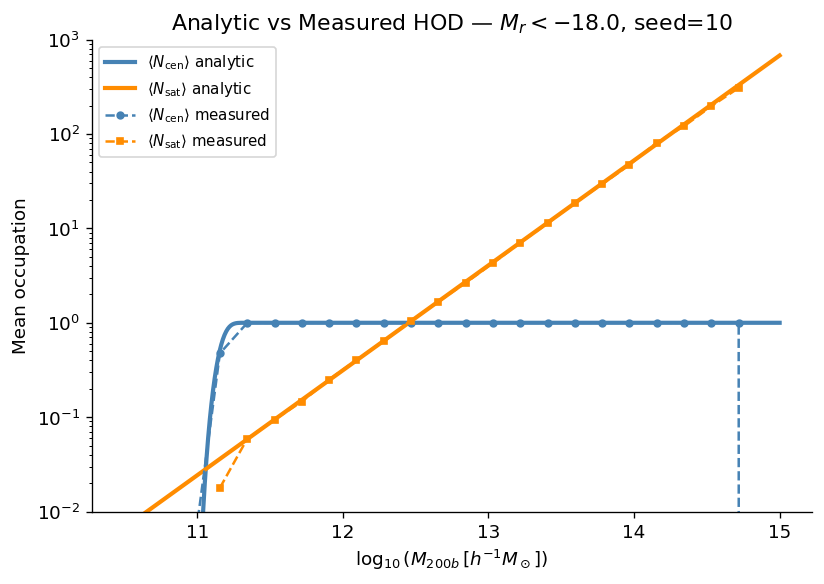

Max |⟨Ncen⟩_meas − ⟨Ncen⟩_analytic| = 0.0423  (< 0.10) ✓


In [13]:
# ---- binned occupation: measured (from mock_base) vs analytic (from BASE_HOD) ----
lgm_all  = np.log10(halos[MASSDEF])
lgm_bins = np.linspace(10.5, 15.0, 25)
lgm_cen  = 0.5 * (lgm_bins[1:] + lgm_bins[:-1])

cen_halo_idx = mock_base['halo_idx'][ mock_base['is_central']]
sat_halo_idx = mock_base['halo_idx'][~mock_base['is_central']]

ncen_mask   = np.zeros(halos.size, dtype=bool)
nsat_counts = np.zeros(halos.size, dtype=int)
ncen_mask[cen_halo_idx] = True
np.add.at(nsat_counts, sat_halo_idx, 1)

ncen_meas = np.zeros(len(lgm_cen))
nsat_meas = np.zeros(len(lgm_cen))
for b in range(len(lgm_cen)):
    mask = (lgm_all >= lgm_bins[b]) & (lgm_all < lgm_bins[b+1])
    if mask.sum() > 0:
        ncen_meas[b] = ncen_mask[mask].mean()
        nsat_meas[b] = nsat_counts[mask].mean()

lgm_fine      = np.linspace(10.5, 15.0, 400)
ncen_analytic = fcen_thresh(lgm_fine, BASE_HOD)
nsat_analytic = Nsat_thresh(lgm_fine, BASE_HOD)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(lgm_fine, ncen_analytic, color='steelblue', lw=2.5, label=r'$\langle N_{\rm cen}\rangle$ analytic')
ax.plot(lgm_fine, np.where(nsat_analytic > 1e-4, nsat_analytic, np.nan),
        color='darkorange', lw=2.5, label=r'$\langle N_{\rm sat}\rangle$ analytic')
ax.plot(lgm_cen, ncen_meas, 'o--', ms=4, color='steelblue', label=r'$\langle N_{\rm cen}\rangle$ measured')
ax.plot(lgm_cen, np.where(nsat_meas > 1e-4, nsat_meas, np.nan),
        's--', ms=4, color='darkorange', label=r'$\langle N_{\rm sat}\rangle$ measured')
ax.set_yscale('log'); ax.set_ylim(1e-2, 1e3)
ax.set_xlabel(r'$\log_{10}(M_{200b}\,[h^{-1}M_\odot])$')
ax.set_ylabel('Mean occupation')
ax.set_title(f'Analytic vs Measured HOD — $M_r < {MR_THRESH}$, seed={SEED}')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# ---- validation: measured ⟨Ncen⟩ within 10pp of analytic, bins with >20 halos only ----
good = np.array([(((lgm_all >= lgm_bins[b]) & (lgm_all < lgm_bins[b+1])).sum() > 20)
                  for b in range(len(lgm_cen))])
ncen_analytic_binned = fcen_thresh(lgm_cen, BASE_HOD)
max_cen_dev = np.max(np.abs(ncen_meas[good] - ncen_analytic_binned[good]))
assert max_cen_dev < 0.10, f'⟨Ncen⟩ deviates by {max_cen_dev:.3f} — check HOD'
print(f'Max |⟨Ncen⟩_meas − ⟨Ncen⟩_analytic| = {max_cen_dev:.4f}  (< 0.10) ✓')

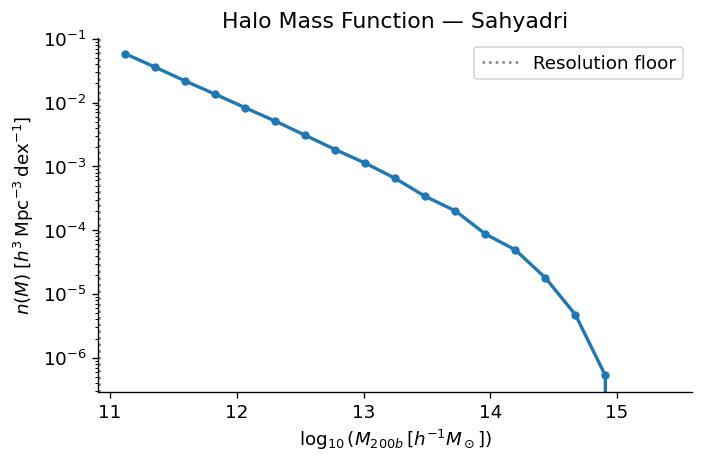

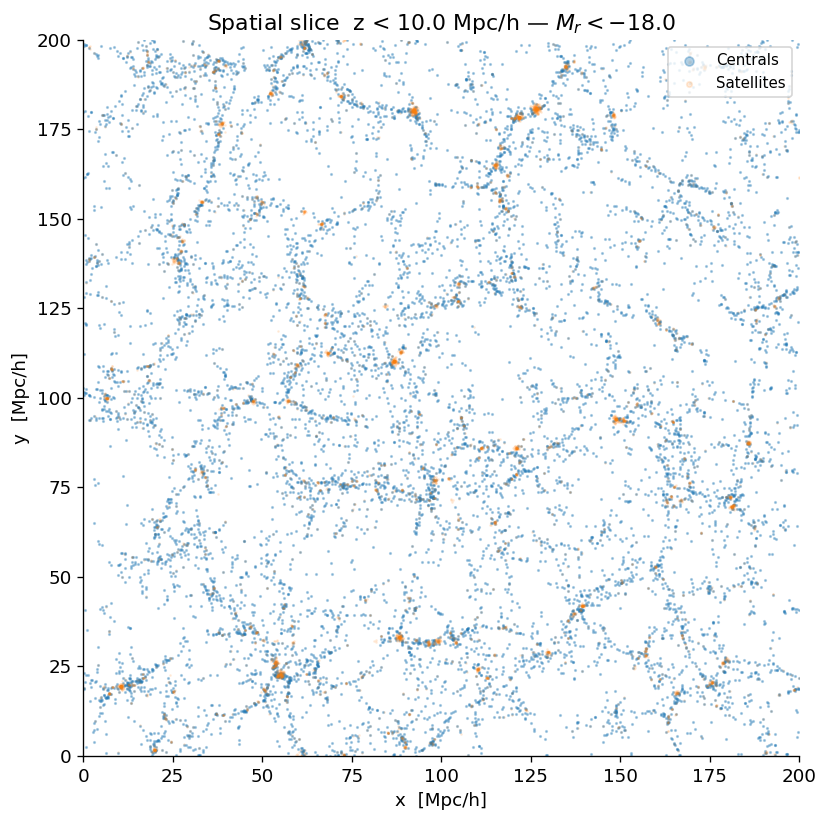

✓ Chapter 7 complete — baseline mock statistics validated.


In [14]:
# ---- HMF ----
hmf_bins  = np.linspace(11.0, 15.5, 20)
hmf_cnt, _ = np.histogram(lgm_all, bins=hmf_bins)
hmf_mid    = 0.5 * (hmf_bins[1:] + hmf_bins[:-1])
hmf_n      = hmf_cnt / (LBOX**3 * (hmf_bins[1] - hmf_bins[0]))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(hmf_mid, hmf_n, 'o-', lw=2, ms=4)
ax.axvline(np.log10(halos[MASSDEF].min()), color='0.5', ls=':', label='Resolution floor')
ax.set_yscale('log')
ax.set_xlabel(r'$\log_{10}(M_{200b}\,[h^{-1}M_\odot])$')
ax.set_ylabel(r'$n(M)\;[h^3\,{\rm Mpc}^{-3}\,{\rm dex}^{-1}]$')
ax.set_title('Halo Mass Function — Sahyadri')
ax.legend(); plt.tight_layout(); plt.show()

# ---- spatial slice ----
fig, ax = plt.subplots(figsize=(7, 7))
slice_depth = 10.0
thin = mock_base['z'] < slice_depth
ax.scatter(mock_base['x'][thin &  mock_base['is_central']],
           mock_base['y'][thin &  mock_base['is_central']],
           s=0.8, c='#1f77b4', alpha=0.35, label='Centrals')
ax.scatter(mock_base['x'][thin & ~mock_base['is_central']],
           mock_base['y'][thin & ~mock_base['is_central']],
           s=0.3, c='#ff7f0e', alpha=0.15, label='Satellites')
ax.set_xlim(0, LBOX); ax.set_ylim(0, LBOX); ax.set_aspect('equal')
ax.set_xlabel('x  [Mpc/h]'); ax.set_ylabel('y  [Mpc/h]')
ax.set_title(f'Spatial slice  z < {slice_depth} Mpc/h — $M_r < {MR_THRESH}$')
ax.legend(markerscale=6, fontsize=9, loc='upper right')
plt.tight_layout(); plt.show()

print('✓ Chapter 7 complete — baseline mock statistics validated.')

Computing baseline wp(rp)...
  N_RP = 50  rp in [0.521, 28.837] Mpc/h
  wp   in [1.09, 113.25] Mpc/h


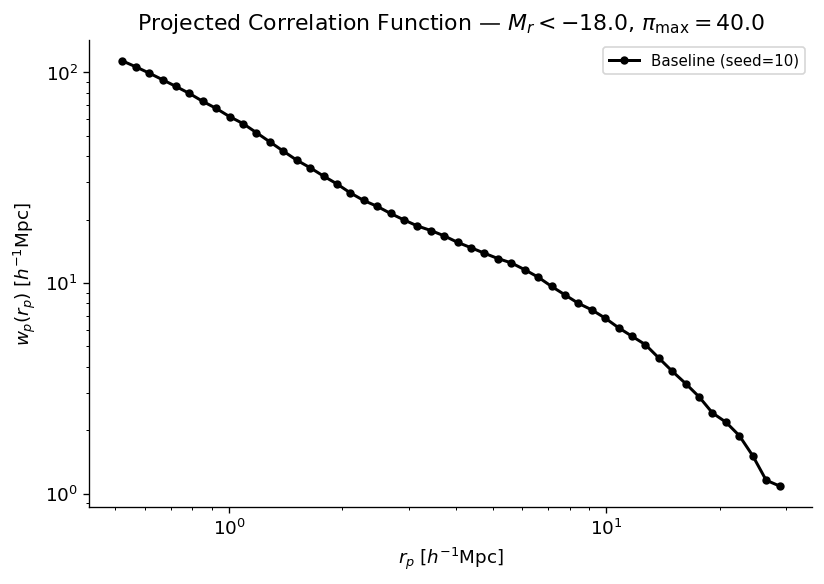

Computing wp for centrals only...
Computing wp for satellites only...


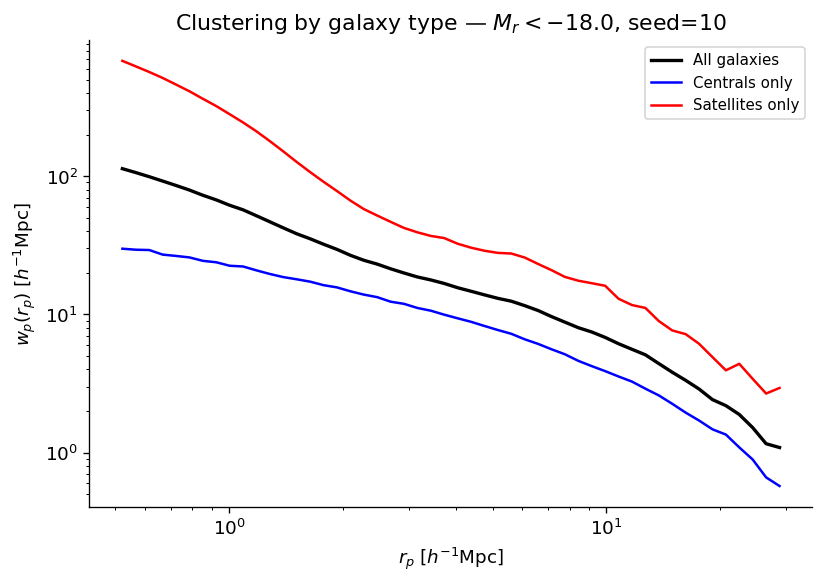

✓ Chapter 8 complete — compute_wp() validated.


In [15]:
RP_BINS = np.logspace(np.log10(RP_MIN), np.log10(RP_MAX), N_RP + 1)

def compute_wp(mock, lbox=None, pimax=None, rp_bins=None, nthreads=None):
    if lbox     is None: lbox     = LBOX
    if pimax    is None: pimax    = PIMAX
    if rp_bins  is None: rp_bins  = RP_BINS
    if nthreads is None: nthreads = NTHREADS

    x = mock['x'].astype(np.float64)
    y = mock['y'].astype(np.float64)
    z = mock['z'].astype(np.float64)

    results = corrfunc_wp(
        lbox, pimax, nthreads,
        binfile=rp_bins,
        X=x, Y=y, Z=z,
        output_rpavg=True,
    )
    rp_arr = np.array([r['rpavg'] for r in results])
    wp_arr = np.array([r['wp']    for r in results])
    return rp_arr, wp_arr

# ---- baseline wp ----
print('Computing baseline wp(rp)...')
rp_base, wp_base = compute_wp(mock_base)

assert np.all(wp_base > 0),          'wp has non-positive values'
assert np.all(np.diff(rp_base) > 0), 'rp bins not monotonically increasing'
assert rp_base[0]  > RP_MIN * 0.9,   'first rp bin too low'
assert rp_base[-1] < RP_MAX * 1.1,   'last rp bin too high'
assert wp_base[0] > wp_base[-1],     'wp not decreasing — clustering problem'

print(f'  N_RP = {len(rp_base)}  rp in [{rp_base[0]:.3f}, {rp_base[-1]:.3f}] Mpc/h')
print(f'  wp   in [{wp_base.min():.2f}, {wp_base.max():.2f}] Mpc/h')

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(rp_base, wp_base, 'ko-', ms=4, lw=1.8, label=f'Baseline (seed={SEED})')
ax.set_xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
ax.set_ylabel(r'$w_p(r_p)\;[h^{-1}\mathrm{Mpc}]$')
ax.set_title(f'Projected Correlation Function — $M_r < {MR_THRESH}$, $\\pi_{{\\max}}={PIMAX}$')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# ---- centrals vs satellites split ----
print('Computing wp for centrals only...')
rp_cen, wp_cen = compute_wp({
    'x': mock_base['x'][ mock_base['is_central']],
    'y': mock_base['y'][ mock_base['is_central']],
    'z': mock_base['z'][ mock_base['is_central']],
})
print('Computing wp for satellites only...')
rp_sat, wp_sat = compute_wp({
    'x': mock_base['x'][~mock_base['is_central']],
    'y': mock_base['y'][~mock_base['is_central']],
    'z': mock_base['z'][~mock_base['is_central']],
})
assert wp_sat[0] > wp_cen[0], 'Satellites not above centrals at small rp'

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(rp_base, wp_base, 'k-', lw=2,   label='All galaxies')
ax.loglog(rp_cen,  wp_cen,  'b-', lw=1.5, label='Centrals only')
ax.loglog(rp_sat,  wp_sat,  'r-', lw=1.5, label='Satellites only')
ax.set_xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
ax.set_ylabel(r'$w_p(r_p)\;[h^{-1}\mathrm{Mpc}]$')
ax.set_title(f'Clustering by galaxy type — $M_r < {MR_THRESH}$, seed={SEED}')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print('✓ Chapter 8 complete — compute_wp() validated.')

Building luminosity catalogue...
... assigning central luminosities
... assigning satellite luminosities

centrals  :  207,998
satellites:  102,687
  centrals  Mr in [-23.5, -18.0] : True
  satellites Mr in [-23.5, -18.0] : True


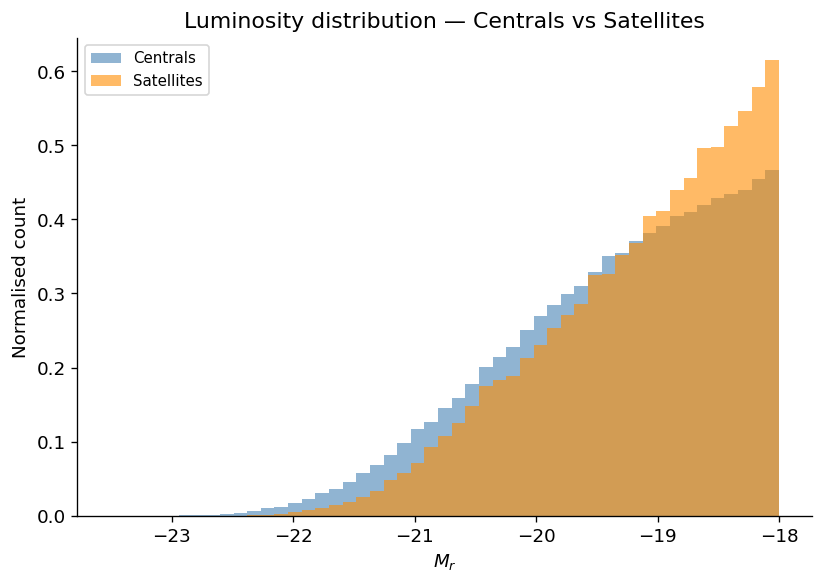


✓ Chapter 9 complete — luminosity catalogue built and validated.


In [16]:
class LuminosityAssigner:
    """
    Assign absolute magnitudes Mr to central and satellite galaxies via
    nested-HOD inverse-transform sampling (Smith et al. 2024 BGS HOD).
    Central occupation uses F_spline, NOT erf. Delegates to fcen_thresh()
    and Nsat_thresh() from Chapter 5 — no HOD equations re-implemented here.
    """

    def __init__(self, Mrmax, seed=42, dMr=0.001):
        self.Mrmax = Mrmax
        self.rng   = np.random.RandomState(seed=seed)

        nMr         = int((23.5 + Mrmax) / dMr)
        self.Mrvals = np.linspace(-23.5, Mrmax, nMr)
        self.dMr    = self.Mrvals[1] - self.Mrvals[0]

        self._hod_grid = get_hod_params(self.Mrvals)   # dict of arrays, shape (nMr,)
        self._hod_max  = get_hod_params(self.Mrmax)    # dict of scalars

    def assign_central_luminosity(self, lgm_halos):
        n      = lgm_halos.size
        Mr_cen = np.zeros(n, dtype=float)
        u      = self.rng.rand(n)
        nmax   = self.Mrvals.size - 1

        Pnorm = fcen_thresh(lgm_halos, self._hod_max)

        for h in range(n):
            PcenL = fcen_thresh(lgm_halos[h], self._hod_grid) / Pnorm[h]
            idx   = min(np.searchsorted(PcenL, u[h], side='right'), nmax)
            Mr_cen[h] = self.Mrvals[idx]

        return Mr_cen

    def assign_satellite_luminosities(self, centrals, h):
        Nsat_h  = centrals['Nsat'][h]
        lgmhalo = centrals['lgm'][h]

        PsatL = Nsat_thresh(lgmhalo, self._hod_grid)
        norm  = Nsat_thresh(lgmhalo, self._hod_max)

        if norm <= 0.0:
            return np.full(Nsat_h, self.Mrmax)

        PsatL /= norm
        u   = self.rng.rand(Nsat_h)
        idx = np.clip(np.searchsorted(PsatL, u, side='left'), 0, self.Mrvals.size - 1)
        return self.Mrvals[idx]


# ---- build centrals / satellites structured arrays ----
print('Building luminosity catalogue...')
mm = LuminosityAssigner(Mrmax=MR_THRESH, seed=42)

cen_halo_idx = mock_base['halo_idx'][mock_base['is_central']]

centrals = np.zeros(cen_halo_idx.size, dtype=[
    ('haloid', 'int64'), ('lgm', 'f8'),
    ('x', 'f8'), ('y', 'f8'), ('z', 'f8'),
    ('Mr', 'f8'), ('Nsat', 'i4'),
])
centrals['haloid'] = cen_halo_idx
centrals['lgm']    = np.log10(halos[MASSDEF][cen_halo_idx])
centrals['x']      = mock_base['x'][mock_base['is_central']]
centrals['y']      = mock_base['y'][mock_base['is_central']]
centrals['z']      = mock_base['z'][mock_base['is_central']]

nsat_per_halo = np.zeros(halos.size, dtype=int)
sat_hidx = mock_base['halo_idx'][~mock_base['is_central']]
np.add.at(nsat_per_halo, sat_hidx, 1)
centrals['Nsat'] = nsat_per_halo[cen_halo_idx]

print('... assigning central luminosities')
centrals['Mr'] = mm.assign_central_luminosity(centrals['lgm'])

Nsat_tot = int(centrals['Nsat'].sum())
satellites = np.zeros(Nsat_tot, dtype=[
    ('haloid', 'int64'), ('lgm', 'f8'),
    ('x', 'f8'), ('y', 'f8'), ('z', 'f8'),
    ('Mr', 'f8'),
])

sat_mask  = ~mock_base['is_central']
satellites['x']      = mock_base['x'][sat_mask]
satellites['y']      = mock_base['y'][sat_mask]
satellites['z']      = mock_base['z'][sat_mask]
satellites['haloid'] = mock_base['halo_idx'][sat_mask]
satellites['lgm']    = np.log10(halos[MASSDEF][satellites['haloid'].astype(int)])

print('... assigning satellite luminosities')
s_lo = 0
for h in range(centrals.size):
    s_hi = s_lo + centrals['Nsat'][h]
    if centrals['Nsat'][h] > 0:
        satellites['Mr'][s_lo:s_hi] = mm.assign_satellite_luminosities(centrals, h)
    s_lo = s_hi

# ---- validation ----
print(f'\ncentrals  : {centrals.size:>8,}')
print(f'satellites: {satellites.size:>8,}')

cen_ok = np.all((centrals['Mr']  >= -23.5) & (centrals['Mr']  <= MR_THRESH))
sat_ok = np.all((satellites['Mr'] >= -23.5) & (satellites['Mr'] <= MR_THRESH))
print(f'  centrals  Mr in [-23.5, {MR_THRESH}] : {cen_ok}')
print(f'  satellites Mr in [-23.5, {MR_THRESH}] : {sat_ok}')
assert cen_ok, 'Central Mr out of range'
assert sat_ok, 'Satellite Mr out of range'

fig, ax = plt.subplots(figsize=(7, 5))
bins_mr = np.linspace(-23.5, MR_THRESH, 50)
ax.hist(centrals['Mr'],   bins=bins_mr, color='steelblue',  alpha=0.6, density=True, label='Centrals')
ax.hist(satellites['Mr'], bins=bins_mr, color='darkorange', alpha=0.6, density=True, label='Satellites')
ax.set_xlabel(r'$M_r$')
ax.set_ylabel('Normalised count')
ax.set_title('Luminosity distribution — Centrals vs Satellites')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print('\n✓ Chapter 9 complete — luminosity catalogue built and validated.')

In [17]:
HOD_PARAM_NAMES = ['Mcut', 'M1', 'M0', 'sigma', 'alpha']
DELTAS = [0.050, 0.025]
DELTA_STABLE = 0.025

def perturb_params(hod_params, param_name, factor):
    """Return a new HOD dict with one parameter multiplied by `factor`. Does not mutate input."""
    new_params = dict(hod_params)
    new_params[param_name] = hod_params[param_name] * factor
    return new_params

# ---- immutability check ----
_base_before = dict(BASE_HOD)
_test_perturbed = perturb_params(BASE_HOD, 'Mcut', 1.05)
assert BASE_HOD == _base_before,                    'perturb_params mutated BASE_HOD!'
assert _test_perturbed['Mcut'] != BASE_HOD['Mcut'], 'perturbation not applied'
assert _test_perturbed['M1']   == BASE_HOD['M1'],   'unperturbed param changed'
print('perturb_params immutability check: ✓')

# ---- perturbation table ----
print(f"\nPerturbation table  (baseline Mr = {MR_THRESH}):")
print(f"{'Param':<8}  {'Baseline':>14}  ", end='')
for delta in DELTAS:
    print(f"  {f'+{100*delta:.1f}%':>10}  {f'-{100*delta:.1f}%':>10}", end='')
print()
print('-' * 80)
for pname in HOD_PARAM_NAMES:
    base_val = BASE_HOD[pname]
    print(f"{pname:<8}  {base_val:>14.6g}", end='')
    for delta in DELTAS:
        p_plus  = perturb_params(BASE_HOD, pname, 1 + delta)
        p_minus = perturb_params(BASE_HOD, pname, 1 - delta)
        print(f"  {p_plus[pname]:>10.6g}  {p_minus[pname]:>10.6g}", end='')
    print()

print('\n✓ Chapter 10 complete — perturbation framework validated.')

perturb_params immutability check: ✓

Perturbation table  (baseline Mr = -18.0):
Param           Baseline         +5.0%       -5.0%       +2.5%       -2.5%
--------------------------------------------------------------------------------
Mcut         1.42569e+11  1.49697e+11  1.3544e+11  1.46133e+11  1.39005e+11
M1           2.83813e+12  2.98004e+12  2.69623e+12  2.90909e+12  2.76718e+12
M0            1.2764e+07  1.34022e+07  1.21258e+07  1.30831e+07  1.24449e+07
sigma          0.0710564   0.0746092   0.0675035   0.0728328   0.0692799
alpha            1.11194     1.16754     1.05634     1.13974     1.08414

✓ Chapter 10 complete — perturbation framework validated.


In [18]:
MASS_PARAMS = ['Mcut', 'M1', 'M0']  # mass-valued HOD params — derivative taken w.r.t. log10(mass)

def get_dtheta(param, delta):
    """Finite-difference denominator for a ±delta relative perturbation.
    Mass params: derivative is w.r.t. log10(mass) (denominator is base-independent).
    Non-mass params: derivative is w.r.t. the linear value, as before."""
    if param in MASS_PARAMS:
        return np.log10(1.0 + delta) - np.log10(1.0 - delta)
    else:
        return BASE_HOD[param] * 2.0 * delta

print('MASS_PARAMS:', MASS_PARAMS)
print('get_dtheta sanity check — should be base-independent for mass params:')
for delta in DELTAS:
    print(f'  delta={delta}: get_dtheta("Mcut", delta) = {get_dtheta("Mcut", delta):.6f}  '
          f'get_dtheta("sigma", delta) = {get_dtheta("sigma", delta):.6f}')

MASS_PARAMS: ['Mcut', 'M1', 'M0']
get_dtheta sanity check — should be base-independent for mass params:
  delta=0.05: get_dtheta("Mcut", delta) = 0.043466  get_dtheta("sigma", delta) = 0.007106
  delta=0.025: get_dtheta("Mcut", delta) = 0.021719  get_dtheta("sigma", delta) = 0.003553


In [19]:
derivs     = {p: {} for p in HOD_PARAM_NAMES}
wp_results = {p: {} for p in HOD_PARAM_NAMES}

for param in HOD_PARAM_NAMES:
    for delta in DELTAS:
        p_plus  = perturb_params(BASE_HOD, param, 1.0 + delta)
        p_minus = perturb_params(BASE_HOD, param, 1.0 - delta)

        print(f'\n── {param}  δ = ±{100*delta:.1f}% ──')
        print(f'  {param}: {BASE_HOD[param]:.6g} → +{100*delta:.1f}%: {p_plus[param]:.6g}'
              f'  |  -{100*delta:.1f}%: {p_minus[param]:.6g}')

        mock_plus  = generate_mock(halos, p_plus,  seed=SEED, verbose=False)
        mock_minus = generate_mock(halos, p_minus, seed=SEED, verbose=False)

        ngal_p = mock_plus['ncen_total']  + mock_plus['nsat_total']
        ngal_m = mock_minus['ncen_total'] + mock_minus['nsat_total']
        print(f'  N_gal: +{100*delta:.1f}% = {ngal_p:,}   -{100*delta:.1f}% = {ngal_m:,}')

        rp_p, wp_p = compute_wp(mock_plus)
        rp_m, wp_m = compute_wp(mock_minus)

        wp_results[param][delta] = (rp_p, wp_p, wp_m)

        dtheta = get_dtheta(param, delta)   # <-- changed line
        dwp    = (wp_p - wp_m) / dtheta
        derivs[param][delta] = (rp_p, dwp)

        del mock_plus, mock_minus
        gc.collect()

print('\n✓ Derivative loop complete.')


── Mcut  δ = ±5.0% ──
  Mcut: 1.42569e+11 → +5.0%: 1.49697e+11  |  -5.0%: 1.3544e+11
  N_gal: +5.0% = 301,454   -5.0% = 321,892

── Mcut  δ = ±2.5% ──
  Mcut: 1.42569e+11 → +2.5%: 1.46133e+11  |  -2.5%: 1.39005e+11
  N_gal: +2.5% = 306,004   -2.5% = 316,162

── M1  δ = ±5.0% ──
  M1: 2.83813e+12 → +5.0%: 2.98004e+12  |  -5.0%: 2.69623e+12
  N_gal: +5.0% = 305,564   -5.0% = 316,740

── M1  δ = ±2.5% ──
  M1: 2.83813e+12 → +2.5%: 2.90909e+12  |  -2.5%: 2.76718e+12
  N_gal: +2.5% = 307,948   -2.5% = 313,916

── M0  δ = ±5.0% ──
  M0: 1.2764e+07 → +5.0%: 1.34022e+07  |  -5.0%: 1.21258e+07
  N_gal: +5.0% = 310,685   -5.0% = 310,658

── M0  δ = ±2.5% ──
  M0: 1.2764e+07 → +2.5%: 1.30831e+07  |  -2.5%: 1.24449e+07
  N_gal: +2.5% = 310,685   -2.5% = 310,685

── sigma  δ = ±5.0% ──
  sigma: 0.0710564 → +5.0%: 0.0746092  |  -5.0%: 0.0675035
  N_gal: +5.0% = 310,544   -5.0% = 310,493

── sigma  δ = ±2.5% ──
  sigma: 0.0710564 → +2.5%: 0.0728328  |  -2.5%: 0.0692799
  N_gal: +2.5% = 310,842   -2.

Derivative plots:


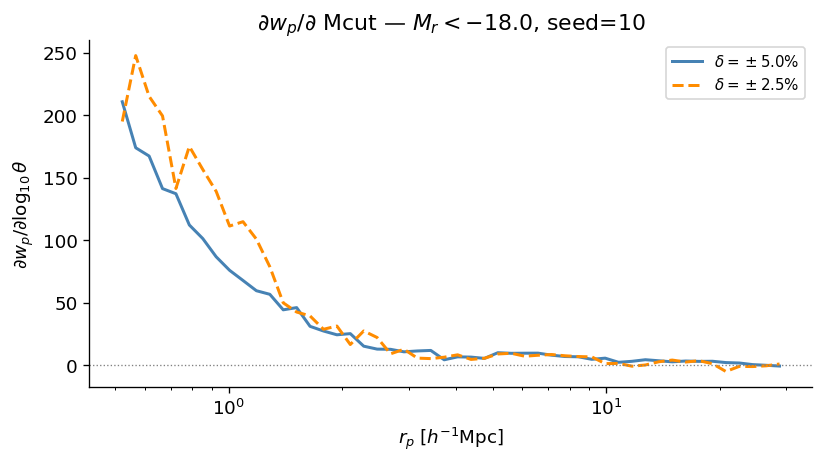

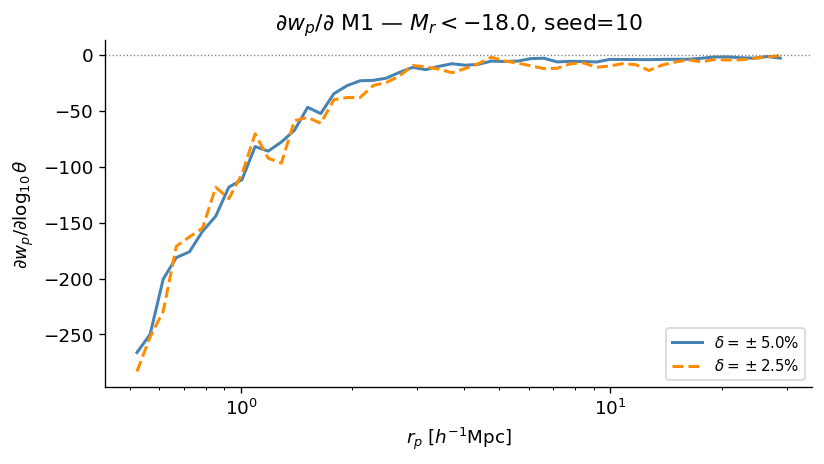

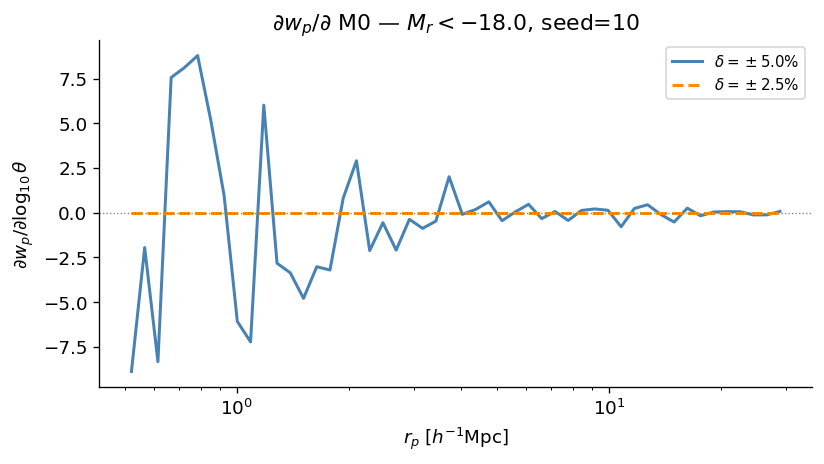

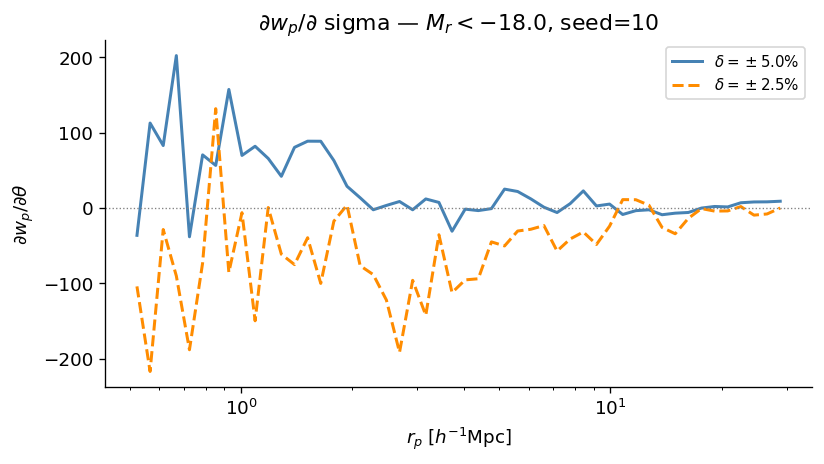

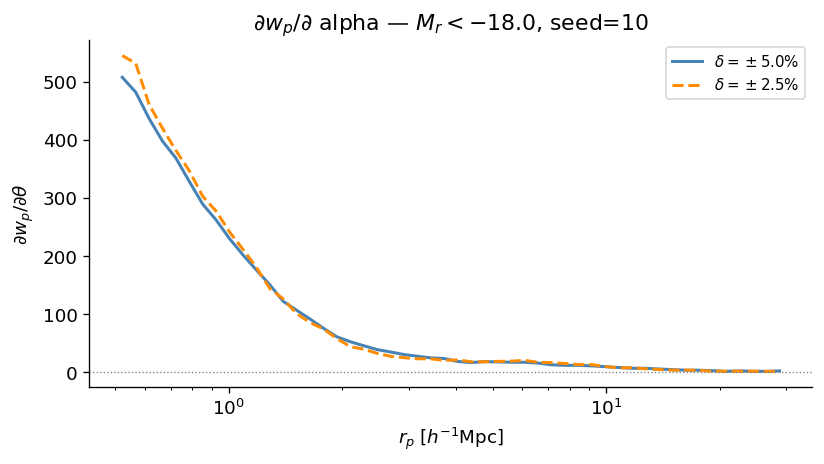


=== Step-size convergence check ===
  Max |d5% − d2.5%| / max(|d5%|, |d2.5%|) per parameter

  Parameter    Max rel. diff    Converged?
  ----------------------------------------
  Mcut                1.7268  ✗  → needs averaging (Ch 11b)
  M1                  0.8183  ✗  → needs averaging (Ch 11b)
  M0                  1.0000  ✗  → needs averaging (Ch 11b)
  sigma               1.9660  ✗  → needs averaging (Ch 11b)
  alpha               0.3572  ✗  → needs averaging (Ch 11b)

Parameters requiring multi-seed averaging: ['Mcut', 'M1', 'M0', 'sigma', 'alpha']

✓ Chapter 11 complete — derivative engine run.


In [20]:
# ---- per-parameter derivative plots ----
print('Derivative plots:')
for param in HOD_PARAM_NAMES:
    fig, ax = plt.subplots(figsize=(7, 4))
    for delta, ls, col in zip(DELTAS, ['-', '--'], ['steelblue', 'darkorange']):
        rp, dwp = derivs[param][delta]
        ax.plot(rp, dwp, ls=ls, color=col, lw=1.8, label=f'$\\delta = \\pm{100*delta:.1f}\\%$')
    ax.axhline(0, color='gray', lw=0.8, ls=':')
    ax.set_xscale('log')
    ax.set_xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
    ylabel = r'$\partial w_p / \partial\log_{10}\theta$' if param in MASS_PARAMS else r'$\partial w_p / \partial\theta$'
    ax.set_ylabel(ylabel)
    ax.set_title(f'$\\partial w_p / \\partial$ {param} — $M_r < {MR_THRESH}$, seed={SEED}')
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()

# ---- convergence table: does the δ=5% derivative agree with δ=2.5%? ----
CONVERGENCE_TOL = 0.15

print('\n=== Step-size convergence check ===')
print('  Max |d5% − d2.5%| / max(|d5%|, |d2.5%|) per parameter\n')
print(f"  {'Parameter':<10}  {'Max rel. diff':>14}  {'Converged?':>12}")
print('  ' + '-' * 40)

NOISY_PARAMS = []
all_converged = True
for param in HOD_PARAM_NAMES:
    _, d5  = derivs[param][0.050]
    _, d25 = derivs[param][0.025]
    denom  = np.maximum(np.abs(d5), np.abs(d25))
    mask   = denom > 1e-8
    rel_diff = np.max(np.abs(d5[mask] - d25[mask]) / denom[mask]) if mask.any() else 0.0
    ok = rel_diff < CONVERGENCE_TOL
    if not ok:
        NOISY_PARAMS.append(param)
    all_converged &= ok
    flag = '✓' if ok else '✗  → needs averaging (Ch 11b)'
    print(f"  {param:<10}  {rel_diff:>14.4f}  {flag}")

print()
if all_converged:
    print('All derivatives converged within 15% — no averaging needed.')
else:
    print(f'Parameters requiring multi-seed averaging: {NOISY_PARAMS}')
print('\n✓ Chapter 11 complete — derivative engine run.')

In [21]:
_diag_param = 'sigma'   # reliably shows drift in the source notebook

In [ ]:
N_REALIZATIONS = 15   # number of random seeds to average over

wp_plus_stack_all  = {p: [] for p in NOISY_PARAMS}
wp_minus_stack_all = {p: [] for p in NOISY_PARAMS}

if not NOISY_PARAMS:
    print('No noisy parameters identified in Ch 11 — skipping multi-seed loop.')
else:
    for real_seed in range(N_REALIZATIONS):
        print(f'\n── Realization {real_seed+1:2d}/{N_REALIZATIONS}  (seed={real_seed}) ──')
        for param in NOISY_PARAMS:
            p_plus  = perturb_params(BASE_HOD, param, 1.0 + DELTA_STABLE)
            p_minus = perturb_params(BASE_HOD, param, 1.0 - DELTA_STABLE)

            mock_plus  = generate_mock(halos, p_plus,  seed=real_seed, verbose=False)
            mock_minus = generate_mock(halos, p_minus, seed=real_seed, verbose=False)

            _, wp_p = compute_wp(mock_plus)
            _, wp_m = compute_wp(mock_minus)

            wp_plus_stack_all[param].append(wp_p)
            wp_minus_stack_all[param].append(wp_m)

            del mock_plus, mock_minus
            gc.collect()

    # ---- averaged derivatives ----
    derivs_averaged = {}
    print('\n\n=== Averaged derivatives ===')
    for param in NOISY_PARAMS:
        wp_plus_mean  = np.mean(wp_plus_stack_all[param],  axis=0)
        wp_minus_mean = np.mean(wp_minus_stack_all[param], axis=0)
        wp_plus_std   = np.std( wp_plus_stack_all[param],  axis=0, ddof=1)
        wp_minus_std  = np.std( wp_minus_stack_all[param], axis=0, ddof=1)

        dtheta   = get_dtheta(param, DELTA_STABLE)   # <-- log-mass fix applied here
        dwp_mean = (wp_plus_mean - wp_minus_mean) / dtheta
        dwp_err  = np.sqrt(wp_plus_std**2 + wp_minus_std**2) / (dtheta * np.sqrt(N_REALIZATIONS))

        rp_ref, _ = derivs[param][DELTA_STABLE]
        derivs_averaged[param] = (rp_ref, dwp_mean, dwp_err)

        _, dwp_single = derivs[param][DELTA_STABLE]
        rel_change = np.max(np.abs(dwp_mean - dwp_single)) / max(np.max(np.abs(dwp_mean)), 1e-30)
        print(f'  {param:<8}  max rel change vs single-realization: {rel_change:.4f}')

    print(f'\nAveraging complete ({N_REALIZATIONS} realizations).')


── Realization  1/15  (seed=0) ──

── Realization  2/15  (seed=1) ──

── Realization  3/15  (seed=2) ──

── Realization  4/15  (seed=3) ──


In [ ]:
STABILIZATION_WINDOW = 5
STABILIZATION_TOL    = 0.05
bin_idx = 5

convergence_summary = {}

if not NOISY_PARAMS:
    print('No noisy parameters — stabilisation plot skipped.')
else:
    for param in NOISY_PARAMS:
        p_plus_arr  = np.array(wp_plus_stack_all[param])
        p_minus_arr = np.array(wp_minus_stack_all[param])
        dtheta = get_dtheta(param, DELTA_STABLE)   # <-- log-mass fix applied here

        running = []
        for n in range(1, N_REALIZATIONS + 1):
            avg_plus  = np.mean(p_plus_arr[:n],  axis=0)
            avg_minus = np.mean(p_minus_arr[:n], axis=0)
            deriv     = (avg_plus - avg_minus) / dtheta
            running.append(deriv[bin_idx])
        running = np.array(running)

        n_final    = N_REALIZATIONS
        n_ref      = max(1, n_final - STABILIZATION_WINDOW)
        val_final  = running[n_final - 1]
        val_ref    = running[n_ref - 1]
        rel_change = abs(val_final - val_ref) / max(abs(val_final), 1e-30)
        is_conv    = rel_change < STABILIZATION_TOL
        convergence_summary[param] = (rel_change, is_conv)

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(range(1, N_REALIZATIONS+1), running,
                marker='o', lw=1.8, color='teal', ms=6, label='Running average')
        ax.axhline(val_final, color='red', ls='--', alpha=0.7, lw=1.5,
                   label=f'Final (N={n_final}): {val_final:.4f}')
        ax.axvspan(n_ref, n_final, color='gray', alpha=0.15,
                   label=f'Last {STABILIZATION_WINDOW} realizations')
        ax.set_xlabel('Number of realizations (N)')
        ylabel = f'$\\partial w_p/\\partial\\log_{{10}}$ {param}  (bin {bin_idx})' if param in MASS_PARAMS \
                 else f'$\\partial w_p/\\partial$ {param}  (bin {bin_idx})'
        ax.set_ylabel(ylabel)
        ax.set_title(f'Stabilisation: {param}')
        ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
        plt.tight_layout()
        outpath = OUTPUT_DIR / f'stabilization_{param}.png'
        plt.savefig(outpath, dpi=200, bbox_inches='tight')
        plt.show()
        print(f'Saved: {outpath}')

    print('\n=== Convergence summary ===')
    print(f"  {'Parameter':<10}  {'Rel. change (last 5)':>22}  {'Status':>18}")
    print('  ' + '-' * 55)
    for param in NOISY_PARAMS:
        rel_change, ok = convergence_summary[param]
        status = 'CONVERGED' if ok else 'STILL STABILISING'
        print(f"  {param:<10}  {100*rel_change:>21.2f}%  {status:>18}")

print('\n✓ Chapter 11b complete.')

In [ ]:
FINAL_DERIVS = {}
FINAL_METHOD = {}

for param in HOD_PARAM_NAMES:
    if param in NOISY_PARAMS and 'derivs_averaged' in dir() and param in derivs_averaged:
        rp_ref, dwp_mean, _ = derivs_averaged[param]
        FINAL_DERIVS[param] = dwp_mean
        FINAL_METHOD[param] = f'averaged  N={N_REALIZATIONS}  δ=±{100*DELTA_STABLE:.1f}%'
    else:
        rp_ref, dwp_single  = derivs[param][0.025]
        FINAL_DERIVS[param] = dwp_single
        FINAL_METHOD[param] = 'single-realization  δ=±2.5%'

print("=" * 78)
print("FINAL DERIVATIVES   d(wp) / d(theta)  [d(wp)/d(log10 theta) for mass params]")
print(f'Sample: Mr < {MR_THRESH},  seed = {SEED},  pimax = {PIMAX} h⁻¹ Mpc')
print("=" * 78)
print('Method per parameter:')
for param in HOD_PARAM_NAMES:
    unit = 'log10-mass' if param in MASS_PARAMS else 'linear'
    print(f'  {param:<8} : {FINAL_METHOD[param]}   [{unit}]')
print()

header = f"{'rp':>10}" + ''.join(f"  {p:>14}" for p in HOD_PARAM_NAMES)
print(header)
print('-' * len(header))
for b in range(N_RP):
    row = f"{rp_ref[b]:>10.4f}"
    for param in HOD_PARAM_NAMES:
        row += f"  {FINAL_DERIVS[param][b]:>14.4f}"
    print(row)

outfile = OUTPUT_DIR / f'wp_derivatives_Mr{abs(MR_THRESH):.0f}_seed{SEED}.npz'

save_dict = {
    'rp':        rp_ref,
    'wp_base':   wp_base,
    'rp_base':   rp_base,
    'seed':      np.int64(SEED),
    'Mr_thresh': np.float64(MR_THRESH),
    'pimax':     np.float64(PIMAX),
    'Lbox':      np.float64(LBOX),
    'mass_params': np.array(MASS_PARAMS),
}
for pname in HOD_PARAM_NAMES:
    save_dict[f'base_{pname}']        = np.float64(BASE_HOD[pname])
    save_dict[f'dwp_d{pname}_FINAL']  = FINAL_DERIVS[pname]
    save_dict[f'dwp_d{pname}_method'] = FINAL_METHOD[pname]
    for delta in [0.050, 0.025]:
        rp_d, dwp_d = derivs[pname][delta]
        save_dict[f'dwp_d{pname}_delta{int(1000*delta):03d}'] = dwp_d

np.savez(outfile, **save_dict)
print(f'\nSaved {len(save_dict)} arrays → {outfile}')

_chk = np.load(outfile, allow_pickle=True)
assert set(HOD_PARAM_NAMES).issubset(
    {k.split('dwp_d')[-1].split('_FINAL')[0] for k in _chk.files if 'FINAL' in k}
), 'Not all FINAL derivatives present in saved file'
print(f'Reload verification: all {len(HOD_PARAM_NAMES)} FINAL derivatives present ✓')

print()
for param in HOD_PARAM_NAMES:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(rp_ref, FINAL_DERIVS[param], color='crimson', lw=2.2)
    ax.axhline(0, color='gray', lw=0.8, ls=':')
    ax.set_xscale('log')
    ax.set_xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
    ylabel = r'$\partial w_p / \partial\log_{10}\theta$' if param in MASS_PARAMS else r'$\partial w_p / \partial\theta$'
    ax.set_ylabel(ylabel)
    ax.set_title(f'FINAL  $\\partial w_p / \\partial$ {param}\n({FINAL_METHOD[param]})')
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

print()
print('=' * 70)
print('NOTEBOOK COMPLETE')
print('=' * 70)
print(f'  Halo catalogue  : Sahyadri default2048,  {halos.size:,} halos')
print(f'  HOD model       : Smith et al. (2024) BGS, F_spline')
print(f'  Mr threshold    : {MR_THRESH}')
print(f'  Galaxies (base) : {mock_base["ncen_total"]+mock_base["nsat_total"]:,}')
print(f'  Parameters      : {HOD_PARAM_NAMES}')
print(f'  Output file     : {outfile}')

In [ ]:
print("=" * 78)
print("FINAL PIPELINE VERIFICATION")
print("=" * 78)

final_outfile = OUTPUT_DIR / f'wp_derivatives_Mr{abs(int(MR_THRESH))}_seed{SEED}.npz'

if final_outfile.exists():
    data = np.load(final_outfile, allow_pickle=True)
    print(f"Successfully loaded archive: {final_outfile.name}")
    print(f"Stored keys in archive  : {list(data.keys())}")
    print(f"rp range                : [{data['rp'].min():.3f}, {data['rp'].max():.3f}] h⁻¹ Mpc")
    print(f"Baseline galaxies       : {int(data['wp_base'].size)} rp bins evaluated")
    if 'mass_params' in data:
        print(f"Mass params (log10 deriv): {list(data['mass_params'])}")

    fig, ax = plt.subplots(figsize=(8, 5))
    for pname in HOD_PARAM_NAMES:
        key = f'dwp_d{pname}_FINAL'
        if key in data:
            label = f'$\\partial w_p / \\partial \\log_{{10}}{pname}$' if pname in MASS_PARAMS \
                    else f'$\\partial w_p / \\partial {pname}$'
            ax.plot(data['rp'], data[key], lw=2, label=label)

    ax.axhline(0, color='gray', ls=':', lw=0.8)
    ax.set_xscale('log')
    ax.set_xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
    ax.set_ylabel(r'$\partial w_p / \partial\theta$  (mixed units — see legend)')
    ax.set_title(f'Final HOD Derivatives — $M_r < {MR_THRESH}$ (Seed {SEED})')
    ax.legend(fontsize=9, loc='best')
    plt.tight_layout()
    plt.show()

    print("\n✓ Notebook execution and output verification complete!")
else:
    print(f"✗ Warning: Expected output file not found at {final_outfile}")